# Big Dataset Comparison: Logistic Regression vs MLP

This notebook mirrors the small-dataset comparison workflow for the Covertype dataset.

Goal:
- Use one shared split and preprocessing pipeline.
- Compare Logistic Regression (ML) vs MLP (DL) fairly.
- Save metrics, plots, and trained artifacts.

In [1]:
import warnings
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "datasetBig" / "covtype.csv",
    PROJECT_ROOT / "Data Set big" / "covtype.csv",
    PROJECT_ROOT / "Data set big" / "covtype.csv",
    PROJECT_ROOT / "datasetBig" / "covtype.csv",
]


def resolve_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find covtype.csv. Checked: " + ", ".join(str(p) for p in candidates)
    )


DATA_PATH = resolve_existing_path(DATA_CANDIDATES)
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "big_dataset"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for folder in [ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# README guidance allows fixed stratified subsets for heavy training.
USE_TRAIN_SUBSET_FOR_MODELING = True
MAX_TRAIN_SAMPLES = 120000
N_INFERENCE_REPEATS = 50

print(f"Project root: {PROJECT_ROOT}")
print(f"Using dataset: {DATA_PATH}")
print(f"Artifacts folder: {ARTIFACTS_DIR}")

Project root: /teamspace/studios/this_studio
Using dataset: /teamspace/studios/this_studio/dataset/datasetBig/covtype.csv
Artifacts folder: /teamspace/studios/this_studio/artifacts/big_dataset


## 1) Load Big Dataset CSV

Read the local Covertype CSV and split features/target.

In [2]:
df = pd.read_csv(DATA_PATH)

empty_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
if empty_cols:
    df = df.drop(columns=empty_cols)

TARGET_COL = "Cover_Type" if "Cover_Type" in df.columns else df.columns[-1]
X_raw = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()
feature_cols = X_raw.columns.tolist()

display(df.head())
print(f"Shape: {df.shape}")
print(f"Target column: {TARGET_COL}")
print(f"Feature count: {len(feature_cols)}")

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


Shape: (581012, 55)
Target column: Cover_Type
Feature count: 54


## 2) Validate Schema, Labels, and Class Balance

In [3]:
missing_values = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values}")
print(f"Duplicate rows: {duplicate_rows}")

X = X_raw.apply(pd.to_numeric, errors="raise")
y_numeric = pd.to_numeric(y_raw, errors="raise").astype(int)

raw_classes = np.sort(y_numeric.unique())
class_to_index = {cls: idx for idx, cls in enumerate(raw_classes)}
index_to_class = {idx: int(cls) for cls, idx in class_to_index.items()}
y = y_numeric.map(class_to_index).astype(int)
N_CLASSES = len(raw_classes)

print(f"Class count: {N_CLASSES}")
print("Class mapping (internal -> original):", index_to_class)
print("Class balance (normalized):")
print(y.value_counts(normalize=True).sort_index())

Total missing values: 0
Duplicate rows: 0
Class count: 7
Class mapping (internal -> original): {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7}
Class balance (normalized):
Cover_Type
0    0.364605
1    0.487599
2    0.061537
3    0.004728
4    0.016339
5    0.029891
6    0.035300
Name: proportion, dtype: float64


## 3) Build Stratified Train/Validation/Test Split (70/15/15)

Create one fixed split and optionally cap train rows for tractable model tuning.

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

val_ratio_within_train_val = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio_within_train_val,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

X_train_model = X_train.copy()
y_train_model = y_train.copy()

if USE_TRAIN_SUBSET_FOR_MODELING and len(X_train_model) > MAX_TRAIN_SAMPLES:
    X_train_model, _, y_train_model, _ = train_test_split(
        X_train_model,
        y_train_model,
        train_size=MAX_TRAIN_SAMPLES,
        stratify=y_train_model,
        random_state=RANDOM_STATE,
    )

print("Split sizes (full):")
print(f"Train full: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")
print("\nRows used for model fitting:", len(X_train_model))

Split sizes (full):
Train full: 406708
Validation: 87152
Test: 87152

Rows used for model fitting: 120000


## 4) Shared Preprocessing + Metric Helpers

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


def get_class_scores(model, X_input):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)
    raise ValueError(f"Model {type(model).__name__} does not expose predict_proba.")


def compute_common_metrics(y_true, y_pred, y_score):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

    if y_score.ndim == 2 and y_score.shape[1] > 2:
        metrics["roc_auc"] = float(
            roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
        )
    else:
        positive_score = y_score[:, 1] if y_score.ndim == 2 else y_score
        metrics["roc_auc"] = float(roc_auc_score(y_true, positive_score))

    return metrics


def compute_macro_roc_curve(y_true, y_score, n_classes):
    if n_classes <= 2:
        positive_score = y_score[:, 1] if y_score.ndim == 2 else y_score
        fpr, tpr, _ = roc_curve(y_true, positive_score)
        return fpr, tpr

    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    grid = np.linspace(0, 1, 400)
    mean_tpr = np.zeros_like(grid)

    for class_idx in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, class_idx], y_score[:, class_idx])
        mean_tpr += np.interp(grid, fpr_i, tpr_i)

    mean_tpr /= n_classes
    return grid, mean_tpr

## 5) Baselines + Manual Validation Search

Train baseline models first, then run compact validation-based hyperparameter search.

In [6]:
baseline_results = []

logreg_baseline = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=300,
    random_state=RANDOM_STATE,
)
start_train = time.perf_counter()
logreg_baseline.fit(X_train_scaled, y_train_model)
logreg_train_time = time.perf_counter() - start_train
logreg_val_pred = logreg_baseline.predict(X_val_scaled)
logreg_val_score = get_class_scores(logreg_baseline, X_val_scaled)
logreg_val_metrics = compute_common_metrics(y_val, logreg_val_pred, logreg_val_score)
baseline_results.append({
    "model": "LogisticRegression_baseline",
    "train_time_sec": logreg_train_time,
    **{f"val_{k}": v for k, v in logreg_val_metrics.items()},
})

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=512,
    max_iter=120,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
)
start_train = time.perf_counter()
mlp_baseline.fit(X_train_scaled, y_train_model)
mlp_train_time = time.perf_counter() - start_train
mlp_val_pred = mlp_baseline.predict(X_val_scaled)
mlp_val_score = get_class_scores(mlp_baseline, X_val_scaled)
mlp_val_metrics = compute_common_metrics(y_val, mlp_val_pred, mlp_val_score)
baseline_results.append({
    "model": "MLP_baseline",
    "train_time_sec": mlp_train_time,
    **{f"val_{k}": v for k, v in mlp_val_metrics.items()},
})

display(pd.DataFrame(baseline_results))


def is_better(candidate, incumbent):
    if incumbent is None:
        return True
    if candidate["val_f1_macro"] > incumbent["val_f1_macro"]:
        return True
    if candidate["val_f1_macro"] == incumbent["val_f1_macro"] and candidate["val_roc_auc"] > incumbent["val_roc_auc"]:
        return True
    return False


def run_manual_validation_search(model_name, base_estimator, param_grid):
    records = []
    best_record = None

    for params in ParameterGrid(param_grid):
        model = clone(base_estimator)
        model.set_params(**params)

        start = time.perf_counter()
        model.fit(X_train_scaled, y_train_model)
        train_time_sec = time.perf_counter() - start

        val_pred = model.predict(X_val_scaled)
        val_score = get_class_scores(model, X_val_scaled)
        val_metrics = compute_common_metrics(y_val, val_pred, val_score)

        record = {
            "model_family": model_name,
            "params": params,
            "train_time_sec": train_time_sec,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        records.append(record)

        if is_better(record, best_record):
            best_record = record

    return pd.DataFrame(records), best_record


logreg_grid = {
    "C": [0.3, 1.0, 3.0],
    "solver": ["lbfgs"],
    "max_iter": [300],
}
mlp_grid = {
    "hidden_layer_sizes": [(128, 64), (256, 128)],
    "alpha": [1e-4, 5e-4],
    "learning_rate_init": [1e-3],
    "max_iter": [120],
}

base_logreg = LogisticRegression(random_state=RANDOM_STATE)
base_mlp = MLPClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    n_iter_no_change=10,
    batch_size=512,
)

search_logreg_df, best_logreg_record = run_manual_validation_search(
    "LogisticRegression", base_logreg, logreg_grid
)
search_mlp_df, best_mlp_record = run_manual_validation_search(
    "MLPClassifier", base_mlp, mlp_grid
)

search_results = pd.concat([search_logreg_df, search_mlp_df], ignore_index=True)
display(
    search_results[[
        "model_family",
        "val_accuracy",
        "val_precision_macro",
        "val_recall_macro",
        "val_f1_macro",
        "val_roc_auc",
        "train_time_sec",
        "params",
    ]].sort_values(["model_family", "val_f1_macro", "val_roc_auc"], ascending=[True, False, False])
)

print("Best validation record (LogReg):")
print(best_logreg_record)
print("\nBest validation record (MLP):")
print(best_mlp_record)

,model,train_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc
0,LogisticRegression_baseline,12.317633,0.724172,0.591923,0.505780,0.525998,0.936601
1,MLP_baseline,69.759890,0.872740,0.815333,0.796182,0.804977,0.985598


,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,train_time_sec,params
2,LogisticRegression,0.724149,0.588879,0.506126,0.526078,0.936612,12.424557,"{'C': 3.0, 'max_iter': 300, 'solver': 'lbfgs'}"
1,LogisticRegression,0.724172,0.591923,0.505780,0.525998,0.936601,12.975115,"{'C': 1.0, 'max_iter': 300, 'solver': 'lbfgs'}"
0,LogisticRegression,0.724126,0.591897,0.503964,0.524654,0.936571,13.406388,"{'C': 0.3, 'max_iter': 300, 'solver': 'lbfgs'}"
4,MLPClassifier,0.900737,0.868656,0.831906,0.849120,0.990752,168.551280,"{'alpha': 0.0001, 'hidden_layer_sizes': (256, ..."
6,MLPClassifier,0.890811,0.870467,0.797996,0.829827,0.989393,118.421797,"{'alpha': 0.0005, 'hidden_layer_sizes': (256, ..."
5,MLPClassifier,0.879372,0.833362,0.792603,0.811377,0.986890,88.069240,"{'alpha': 0.0005, 'hidden_layer_sizes': (128, ..."
3,MLPClassifier,0.872740,0.815333,0.796182,0.804977,0.985598,64.924586,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ..."


Best validation record (LogReg):
{'model_family': 'LogisticRegression', 'params': {'C': 3.0, 'max_iter': 300, 'solver': 'lbfgs'}, 'train_time_sec': 12.424557262000008, 'val_accuracy': 0.724148613915917, 'val_precision_macro': 0.5888786945709509, 'val_recall_macro': 0.5061259864065966, 'val_f1_macro': 0.5260776457469378, 'val_roc_auc': 0.9366121935417786}

Best validation record (MLP):
{'model_family': 'MLPClassifier', 'params': {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001, 'max_iter': 120}, 'train_time_sec': 168.5512796249999, 'val_accuracy': 0.9007366440242335, 'val_precision_macro': 0.8686560085768529, 'val_recall_macro': 0.8319060689908867, 'val_f1_macro': 0.8491196589892359, 'val_roc_auc': 0.9907521802686031}


## 6) Select Best Models, Evaluate on Test, Plot, and Save Artifacts

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
LogisticRegression,0.722611,0.595629,0.506766,0.528366,0.935640
MLPClassifier,0.900920,0.863951,0.834082,0.847688,0.990815


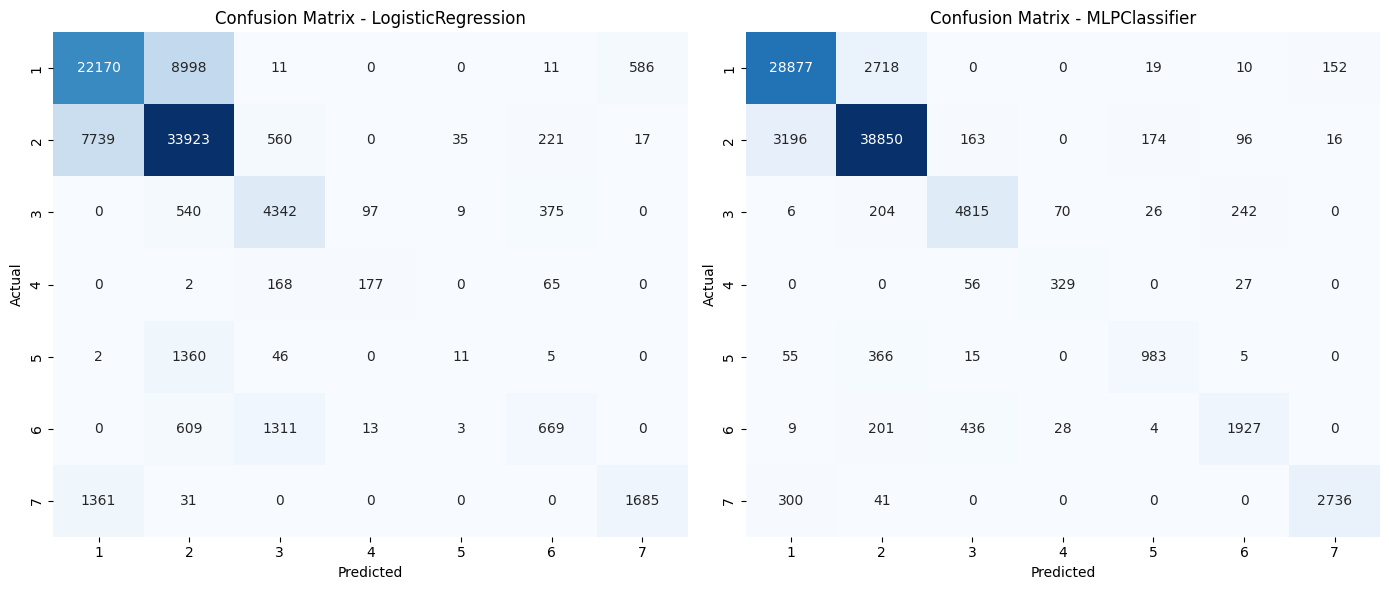

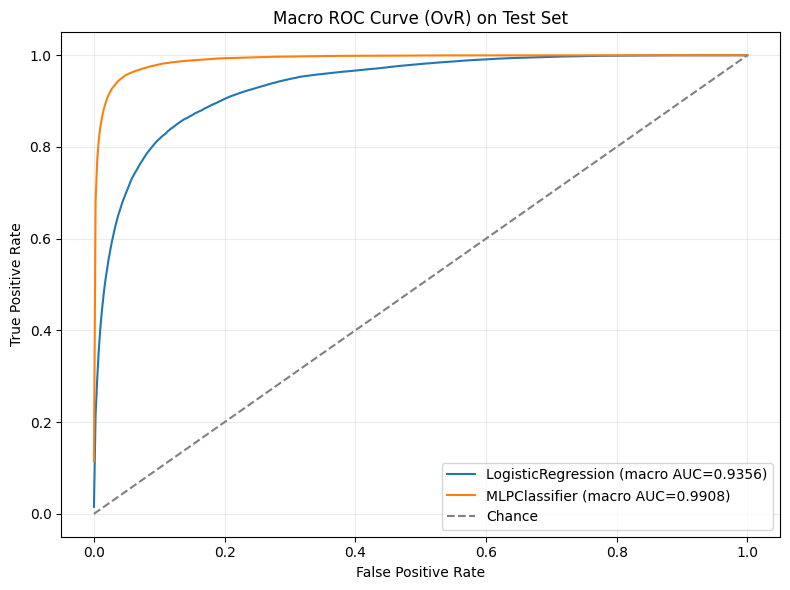

,train_time_sec,inference_total_sec,inference_per_sample_ms
model_family,,,
LogisticRegression,12.351233,0.856648,0.000197
MLPClassifier,190.022453,18.400151,0.004223


,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,train_time_sec,inference_per_sample_ms,best_params
1,MLPClassifier,0.900737,0.868656,0.831906,0.849120,0.990752,0.900920,0.863951,0.834082,0.847688,0.990815,190.022453,0.004223,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [256, ..."
0,LogisticRegression,0.724149,0.588879,0.506126,0.526078,0.936612,0.722611,0.595629,0.506766,0.528366,0.935640,12.351233,0.000197,"{""C"": 3.0, ""max_iter"": 300, ""solver"": ""lbfgs""}"


Saved artifacts:
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/final_comparison_big_dataset.csv
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/final_comparison_big_dataset.json
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/validation_search_results_big_dataset.csv
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/logreg_coefficients_big_dataset.csv
- /teamspace/studios/this_studio/artifacts/big_dataset/figures/confusion_matrices_test.png
- /teamspace/studios/this_studio/artifacts/big_dataset/figures/roc_curves_test.png
- /teamspace/studios/this_studio/artifacts/big_dataset/models/standard_scaler.joblib


In [7]:
selection_plan = {
    "LogisticRegression": {
        "estimator": LogisticRegression(random_state=RANDOM_STATE),
        "best_record": best_logreg_record,
    },
    "MLPClassifier": {
        "estimator": MLPClassifier(
            random_state=RANDOM_STATE,
            early_stopping=True,
            n_iter_no_change=10,
            batch_size=512,
        ),
        "best_record": best_mlp_record,
    },
}

selected_models = {}
selected_model_info = {}
for model_family, cfg in selection_plan.items():
    best_params = cfg["best_record"]["params"]
    model = clone(cfg["estimator"]).set_params(**best_params)

    start_train = time.perf_counter()
    model.fit(X_train_scaled, y_train_model)
    train_time_sec = time.perf_counter() - start_train

    val_pred = model.predict(X_val_scaled)
    val_score = get_class_scores(model, X_val_scaled)
    val_metrics = compute_common_metrics(y_val, val_pred, val_score)

    selected_models[model_family] = model
    selected_model_info[model_family] = {
        "best_params": best_params,
        "train_time_sec": train_time_sec,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

test_results = {}
model_predictions = {}
model_scores = {}
for model_family, model in selected_models.items():
    y_pred = model.predict(X_test_scaled)
    y_score = get_class_scores(model, X_test_scaled)
    test_results[model_family] = compute_common_metrics(y_test, y_pred, y_score)
    model_predictions[model_family] = y_pred
    model_scores[model_family] = y_score

test_results_df = pd.DataFrame(test_results).T
display(test_results_df)

label_names = [str(index_to_class[i]) for i in sorted(index_to_class.keys())]
fig_cm, axes = plt.subplots(1, len(selected_models), figsize=(7 * len(selected_models), 6))
if len(selected_models) == 1:
    axes = [axes]

for ax, (model_family, y_pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {model_family}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
for model_family, y_score in model_scores.items():
    fpr, tpr = compute_macro_roc_curve(y_test, y_score, N_CLASSES)
    auc_value = test_results[model_family]["roc_auc"]
    ax_roc.plot(fpr, tpr, label=f"{model_family} (macro AUC={auc_value:.4f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax_roc.set_title("Macro ROC Curve (OvR) on Test Set")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.25)
plt.tight_layout()
plt.show()

timing_rows = []
for model_family, model in selected_models.items():
    start_infer = time.perf_counter()
    for _ in range(N_INFERENCE_REPEATS):
        _ = model.predict(X_test_scaled)
    infer_total_sec = time.perf_counter() - start_infer

    timing_rows.append(
        {
            "model_family": model_family,
            "train_time_sec": selected_model_info[model_family]["train_time_sec"],
            "inference_total_sec": infer_total_sec,
            "inference_per_sample_ms": (infer_total_sec / (N_INFERENCE_REPEATS * len(X_test_scaled))) * 1000,
        }
    )
timing_df = pd.DataFrame(timing_rows).set_index("model_family")
display(timing_df)

final_rows = []
for model_family in selected_models.keys():
    final_rows.append(
        {
            "model_family": model_family,
            "val_accuracy": selected_model_info[model_family]["val_accuracy"],
            "val_precision_macro": selected_model_info[model_family]["val_precision_macro"],
            "val_recall_macro": selected_model_info[model_family]["val_recall_macro"],
            "val_f1_macro": selected_model_info[model_family]["val_f1_macro"],
            "val_roc_auc": selected_model_info[model_family]["val_roc_auc"],
            "test_accuracy": test_results[model_family]["accuracy"],
            "test_precision_macro": test_results[model_family]["precision_macro"],
            "test_recall_macro": test_results[model_family]["recall_macro"],
            "test_f1_macro": test_results[model_family]["f1_macro"],
            "test_roc_auc": test_results[model_family]["roc_auc"],
            "train_time_sec": timing_df.loc[model_family, "train_time_sec"],
            "inference_per_sample_ms": timing_df.loc[model_family, "inference_per_sample_ms"],
            "best_params": json.dumps(selected_model_info[model_family]["best_params"]),
        }
    )

final_comparison_df = pd.DataFrame(final_rows).sort_values("test_f1_macro", ascending=False)
display(final_comparison_df)

comparison_csv_path = METRICS_DIR / "final_comparison_big_dataset.csv"
comparison_json_path = METRICS_DIR / "final_comparison_big_dataset.json"
search_csv_path = METRICS_DIR / "validation_search_results_big_dataset.csv"
coefficients_csv_path = METRICS_DIR / "logreg_coefficients_big_dataset.csv"

search_results_to_save = search_results.copy()
search_results_to_save["params"] = search_results_to_save["params"].apply(json.dumps)
search_results_to_save.to_csv(search_csv_path, index=False)
final_comparison_df.to_csv(comparison_csv_path, index=False)

with open(comparison_json_path, "w", encoding="utf-8") as f:
    json.dump(final_rows, f, indent=2)

if "LogisticRegression" in selected_models:
    logreg_model = selected_models["LogisticRegression"]
    coef_importance = np.abs(logreg_model.coef_).mean(axis=0)
    coef_df = pd.DataFrame(
        {
            "feature": feature_cols,
            "mean_abs_coefficient": coef_importance,
        }
    ).sort_values("mean_abs_coefficient", ascending=False)
    coef_df.to_csv(coefficients_csv_path, index=False)

for model_family, model in selected_models.items():
    joblib.dump(model, MODELS_DIR / f"{model_family}_best.joblib")
joblib.dump(scaler, MODELS_DIR / "standard_scaler.joblib")

with open(METRICS_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)
with open(METRICS_DIR / "class_mapping.json", "w", encoding="utf-8") as f:
    json.dump(index_to_class, f, indent=2)

cm_plot_path = FIGURES_DIR / "confusion_matrices_test.png"
roc_plot_path = FIGURES_DIR / "roc_curves_test.png"
fig_cm.savefig(cm_plot_path, dpi=200, bbox_inches="tight")
fig_roc.savefig(roc_plot_path, dpi=200, bbox_inches="tight")

print("Saved artifacts:")
print(f"- {comparison_csv_path}")
print(f"- {comparison_json_path}")
print(f"- {search_csv_path}")
print(f"- {coefficients_csv_path}")
print(f"- {cm_plot_path}")
print(f"- {roc_plot_path}")
print(f"- {MODELS_DIR / 'standard_scaler.joblib'}")